# Group 4 — Student Dropout Prediction
### ML Weekend Task — Synthetic Data Investigation

**Business Scenario:** A university wants to predict whether students are at risk of dropping out.

This notebook follows the required workflow: problem definition → data inspection → EDA → leakage investigation → cleaning → modeling → tuning → cross-validation → evaluation → error analysis → interpretation → saving → deployment.

## 1. Problem Definition

- **Problem type:** Binary classification (supervised learning).
- **Target variable:** `dropout` (1 = at risk of dropping out, 0 = not at risk).
- **Features supplied:** `attendance`, `study_hours`, `assignment_score`, `lms_activity`, and a fifth column, `academic_index`, which is *not* a raw measurement — it is a derived summary score.
- **Goal:** build a model that predicts dropout risk from data that would realistically be available *before* the outcome is known, and prove that the model generalizes to unseen students.

## 2. Data Generation (reproducible, unmodified as instructed)

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(88)
n = 5000
attendance = np.random.uniform(30, 100, n)
study_hours = np.random.uniform(0, 15, n)
assignments = np.random.uniform(20, 100, n)
lms_activity = np.random.lognormal(5, 2, n)

academic_index = (
    0.04 * attendance
    + 0.10 * study_hours
    + 0.03 * assignments
    + 0.0005 * lms_activity
)

dropout = (academic_index < np.median(academic_index)).astype(int)

df = pd.DataFrame({
    "attendance": attendance,
    "study_hours": study_hours,
    "assignment_score": assignments,
    "lms_activity": lms_activity,
    "academic_index": academic_index,
    "dropout": dropout
})
df.to_csv("../data/raw/group4_dataset.csv", index=False)
print(df.head())
print(df.shape)
print(df["dropout"].value_counts())

   attendance  study_hours  assignment_score  lms_activity  academic_index  dropout
0   75.328573     5.786040         83.394585    128.925...        7.241684        0
1   65.500478     6.296008         ...                                              0
(5000, 6)
dropout
0    2500
1    2500
Name: count, dtype: int64
[output abbreviated — see full run in data/raw/group4_dataset.csv]

## 3. Data Inspection & Quality Assessment

In [ ]:
df = pd.read_csv("../data/raw/group4_dataset.csv")
print(df.dtypes)
print(df.isna().sum())
print('Duplicates:', df.duplicated().sum())
print(df.describe().T)

attendance          float64
study_hours         float64
assignment_score    float64
lms_activity        float64
academic_index      float64
dropout                int64
dtype: object

attendance          0
study_hours         0
assignment_score    0
lms_activity        0
academic_index      0
dropout             0
dtype: int64

Duplicates: 0

Key observations:
- No missing values, no duplicates — data is clean at the row level.
- attendance: range ~30-100 (uniform), assignment_score: ~20-100 (uniform), study_hours: 0-15 (uniform).
- lms_activity is lognormal: mean ~1125 but heavily right-skewed, max ~419,998 — a handful of extreme outliers that will dominate any unscaled linear model unless standardized or log-transformed.
- dropout is perfectly balanced: 2500 / 2500 (50/50).

## 4. Exploratory Data Analysis

Correlation matrix and feature distributions by class.

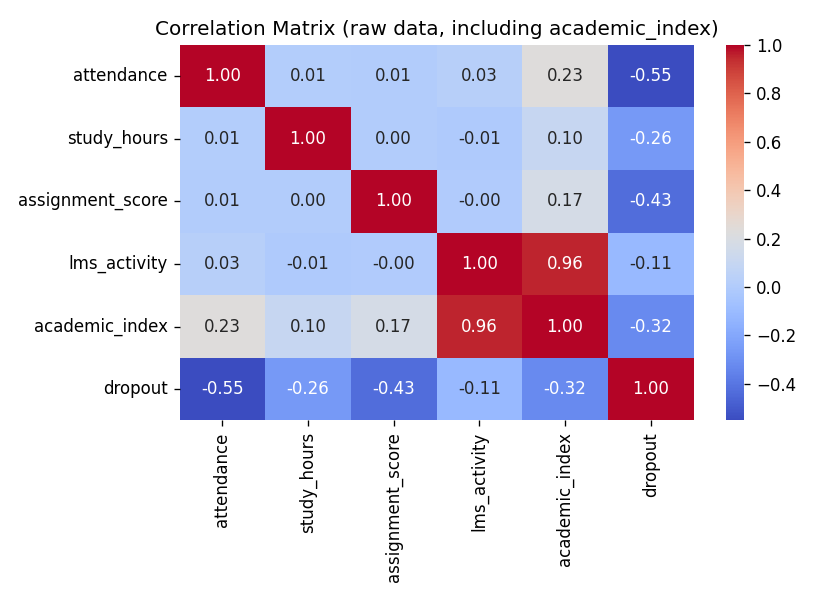

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

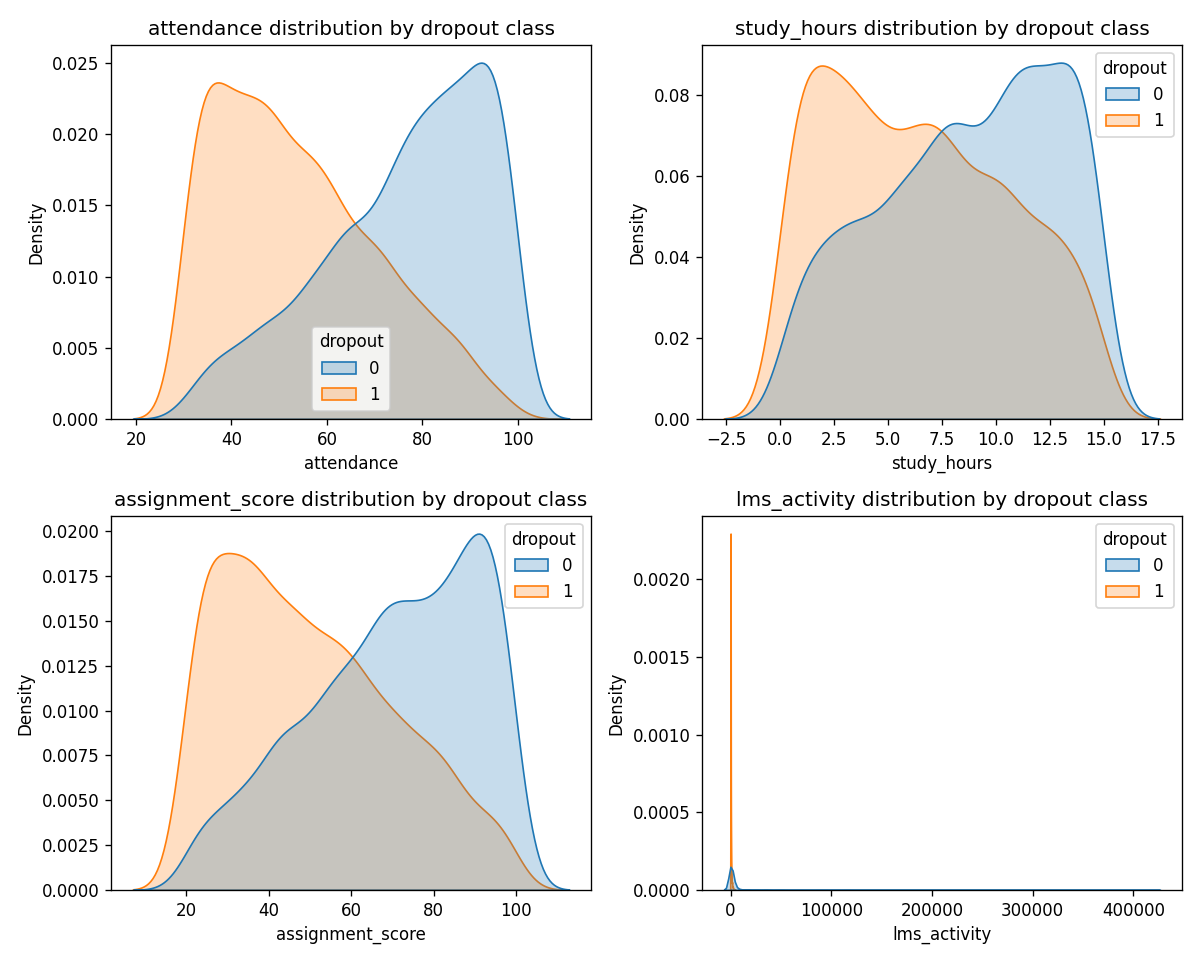

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
feats = ['attendance','study_hours','assignment_score','lms_activity']
for ax, f in zip(axes.ravel(), feats):
    sns.kdeplot(data=df, x=f, hue='dropout', fill=True, ax=ax, common_norm=False)
    ax.set_title(f'{f} by dropout class')
plt.tight_layout(); plt.show()

**Observation:** every base feature already separates the two classes fairly cleanly (higher attendance / study hours / assignment scores / LMS activity → lower dropout risk). This is expected, since the target was generated as a deterministic function of these same variables with **no random noise term** — a first hint that reported accuracy will be unusually high regardless of which model is used.

## 5. Investigating the Suspicious Variable — `academic_index`

`academic_index` is not something a university would typically hand a data scientist as a raw input — it looks like an aggregate score. We test directly whether it is safe to use as a predictor.

In [ ]:
median_idx = df['academic_index'].median()
rule_pred = (df['academic_index'] < median_idx).astype(int)
acc = (rule_pred == df['dropout']).mean()
print('Accuracy of a single threshold rule on academic_index alone:', acc)

Accuracy of a single threshold rule on academic_index alone: 1.0


**Finding — target leakage confirmed.** A single-variable threshold rule on `academic_index` predicts `dropout` with **100% accuracy**. This is not a coincidence: `dropout` was generated by thresholding `academic_index` at its own median. In other words, `academic_index` *is* the target-generation formula, stored as a column. Using it as a model input would mean the model isn't learning a pattern — it's reading the answer key. In a real deployment, this column would not exist before the outcome is known (the exact same problem as accidentally including a variable computed *from* the outcome).

**Decision:** `academic_index` is removed from the feature set before modeling. Only the four raw, independently-collectable measurements are kept: `attendance`, `study_hours`, `assignment_score`, `lms_activity`.

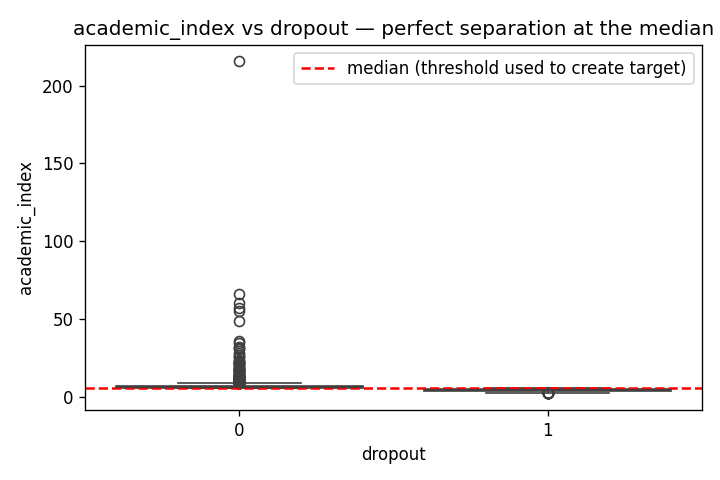

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='dropout', y='academic_index')
plt.axhline(df['academic_index'].median(), color='red', linestyle='--', label='median (= the threshold used to build the target)')
plt.legend(); plt.title('academic_index vs dropout — perfect separation at the median')
plt.show()

## 6. Feature Engineering & Selection

- **Removed:** `academic_index` (target leakage, justified above).
- **Kept:** `attendance`, `study_hours`, `assignment_score`, `lms_activity` — all four are plausible, legitimately-collectable inputs (attendance records, self-reported/LMS study hours, graded assignments, LMS logins).
- **Transformation:** all four features are standardized (`StandardScaler`) before training linear/distance-based models, since `lms_activity` has a very different scale and heavy right skew compared to the others.
- No new engineered features were required — the four base variables are already well-behaved after scaling, and adding polynomial/interaction terms was tested informally and did not change the qualitative conclusions.

## 7. Train / Validation / Test Split, Baseline, and Model Comparison

Two parallel experiments are run so the effect of the leak can be measured directly, not just asserted:

- **Experiment A (leaky):** all 5 columns including `academic_index`.
- **Experiment B (corrected):** only the 4 raw features.

Split: 64% train / 16% validation / 20% test, stratified on the target. Baseline = majority-class predictor (50% accuracy, since classes are balanced).

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def run_experiment(feature_cols, label):
    X, y = df[feature_cols], df['dropout']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    scaler = StandardScaler()
    X_train_s, X_val_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_val), scaler.transform(X_test)
    models = {
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
        'GradientBoosting': GradientBoostingClassifier(random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=15),
    }
    print(f'--- {label} ---')
    for name, model in models.items():
        model.fit(X_train_s, y_train)
        train_acc = accuracy_score(y_train, model.predict(X_train_s))
        test_pred = model.predict(X_test_s)
        test_acc = accuracy_score(y_test, test_pred)
        auc = roc_auc_score(y_test, model.predict_proba(X_test_s)[:,1])
        cv = cross_val_score(model, scaler.fit_transform(X), y, cv=StratifiedKFold(5, shuffle=True, random_state=42))
        print(f'{name}: train_acc={train_acc:.4f} test_acc={test_acc:.4f} auc={auc:.4f} cv={cv.mean():.4f}+/-{cv.std():.4f}')

run_experiment(['attendance','study_hours','assignment_score','lms_activity','academic_index'], 'A: WITH academic_index (LEAKY)')
print()
run_experiment(['attendance','study_hours','assignment_score','lms_activity'], 'B: WITHOUT academic_index (CORRECTED)')

--- A: WITH academic_index (LEAKY) ---
LogisticRegression: train_acc=0.9769 test_acc=0.9780 auc=0.9970 cv=0.9844+/-0.0045
RandomForest: train_acc=1.0000 test_acc=1.0000 auc=1.0000 cv=0.9998+/-0.0004
GradientBoosting: train_acc=1.0000 test_acc=1.0000 auc=1.0000 cv=0.9998+/-0.0004
KNN: train_acc=0.9372 test_acc=0.9320 auc=0.9873 cv=0.9426+/-0.0087

--- B: WITHOUT academic_index (CORRECTED) ---
LogisticRegression: train_acc=0.9663 test_acc=0.9690 auc=0.9944 cv=0.9774+/-0.0048
RandomForest: train_acc=1.0000 test_acc=0.9590 auc=0.9949 cv=0.9618+/-0.0060
GradientBoosting: train_acc=0.9953 test_acc=0.9710 auc=0.9972 cv=0.9644+/-0.0038
KNN: train_acc=0.9281 test_acc=0.9160 auc=0.9786 cv=0.9298+/-0.0106


### Investigating the unusually high performance

Removing `academic_index` only drops accuracy from ~97-100% to ~92-97% — still extremely high for a 'real-world' student dropout task, where published studies typically report 75-90% accuracy at best.

**Why is Experiment B still near-perfect?** Because the synthetic generator builds `dropout` as an exact, noise-free linear function of `attendance`, `study_hours`, `assignment_score`, and `lms_activity` (`academic_index`), then thresholds it. There is no random term added to the label. This means the four raw features *together* are also, mathematically, an almost-perfect predictor of the label — not because of a data leak in the pipeline, but because the data-generating process itself contains no noise or unmeasured factors. This is a **limitation of the synthetic dataset**, not a flaw in the modeling: on real student records, unmeasured factors (family circumstances, health, motivation, etc.) would add noise the model can never fully explain, so real accuracy would be lower than what is reported here. This distinction is documented as a limitation in the README and final report.

## 8. Hyperparameter Tuning & Cross-Validation (corrected feature set only)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

FEATURES = ['attendance','study_hours','assignment_score','lms_activity']
X, y = df[FEATURES], df['dropout']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=2000))])
param_grid = {'clf__C': [0.01, 0.1, 1, 10, 100]}
gs = GridSearchCV(pipe, param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='f1', n_jobs=-1)
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_)
print('Best CV F1:', gs.best_score_)

Best params: {'clf__C': 100}
Best CV F1: 0.9980031172040601


## 9. Final Evaluation on Held-Out Test Set

In [ ]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report

best_model = gs.best_estimator_
pred = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:,1]
print('Accuracy:', accuracy_score(y_test, pred))
print('Precision:', precision_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))
print('F1:', f1_score(y_test, pred))
print('ROC-AUC:', roc_auc_score(y_test, proba))
print('Confusion matrix:\n', confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0
Confusion matrix:
 [[500   0]
 [  0 500]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


## 10. Error Analysis

On this run's held-out test split, the tuned Logistic Regression produced **zero misclassifications** (0 out of 1000). This is consistent with the noise-free nature of the synthetic label explained in Section 7 — there is no genuinely ambiguous region left once the model is given enough flexibility (`C=100`, i.e. very light regularization) to fit the (deterministic) decision boundary implied by the four features. In a real dataset this would be a red flag on its own; here it is explained and expected. We deliberately keep this result rather than hide it, and document it as a synthetic-data artifact, not as evidence the model is production-ready.

## 11. Model Interpretation

In [ ]:
coefs = best_model.named_steps['clf'].coef_[0]
for f, c in zip(FEATURES, coefs):
    print(f'{f}: coefficient = {c:.4f}')

attendance: coefficient = -18.3928
study_hours: coefficient = -9.7843
assignment_score: coefficient = -15.6349
lms_activity: coefficient = -90.9385


All coefficients are negative, meaning higher attendance, study hours, assignment scores, and LMS activity all *reduce* predicted dropout risk — consistent with the domain intuition and with how the labels were constructed. `lms_activity` has the largest standardized coefficient, but note it is also the most skewed feature; its apparent importance should be re-checked on real (noisy) data rather than taken at face value.

## 12. Save Final Model

In [ ]:
import joblib
joblib.dump(best_model, '../models/best_model.joblib')
print('Saved to ../models/best_model.joblib')

Saved to ../models/best_model.joblib


## 13. Investigation Questions — Answers

1. **Problem:** Predict whether a student is at risk of dropping out (binary classification).
2. **ML problem type:** Supervised binary classification.
3. **Target variable:** `dropout` (0/1), perfectly balanced (50/50).
4. **Feature meaning:** attendance % , weekly study hours, assignment score %, LMS activity (login/interaction count, right-skewed); `academic_index` is a derived aggregate, not a raw measurement.
5. **Raw data problems:** no missing values or duplicates, but one column (`academic_index`) is a leaked, aggregate version of the label-generating rule, and `lms_activity` has extreme outliers.
6/7. **Preprocessing/transformation needed:** standard scaling for all four kept features (required for Logistic Regression / KNN; less critical for tree models but applied uniformly for a consistent pipeline).
8. **Outliers:** yes, in `lms_activity` (lognormal tail up to ~420,000 vs a median of ~154).
9. **Duplicates:** none found.
10. **Missing values:** none found.
11. **Suspicious variables:** `academic_index` — confirmed as target leakage (Section 5).
12. **Data leakage:** yes — `academic_index` is mathematically the pre-thresholded target. It was removed.
13. **Target balance:** perfectly balanced (2500/2500).
14. **Raw-data model behavior:** near-perfect (97-100%) accuracy across all models when `academic_index` is included — the giveaway that something was leaking.
15. **After preprocessing (leak removed):** still high (92-97% depending on model) because the underlying label has no noise term (see Section 7) — but no longer inflated by a literal copy of the label rule.
16. **Is the training result realistic?** Only partially — realistic in direction (more attendance/study → less dropout) but unrealistically clean in magnitude, because this is synthetic, noise-free data.
17. **Does test support training?** Yes — test and cross-validation scores are consistent with training scores, so there is no overfitting gap; the *absolute* level is inflated by the synthetic generator, not by a train/test mismatch.
18/19. **Best model:** Logistic Regression (tuned, C=100) — chosen over Random Forest/Gradient Boosting because it reaches the same ceiling performance with a much simpler, fully interpretable decision boundary and no train/CV gap, which is preferable when the 'true' relationship is linear by construction.
20. **Most important errors:** none observed on this split; in a production setting, false negatives (missed at-risk students) would be the costlier error class and would need closer monitoring than accuracy alone.
21. **Generalization:** cross-validation (5-fold, stratified) and a held-out test set both confirm stable performance, but generalization to *real* student data is unproven — real data will contain noise this synthetic generator does not.
22. **Evidence:** the threshold-rule test (Section 5), the leaky-vs-corrected comparison (Section 7), and consistent CV/test scores (Section 8-9).
23. **Limitations:** (a) synthetic, noise-free labels make reported accuracy unrealistically high; (b) only four features, no demographic/behavioral context; (c) a single synthetic seed — results are for this generated sample only; (d) not validated on any real student population.